In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [17]:
# === CELL 1 (MỚI): CẤU HÌNH COLAB, DRIVE & KAGGLE API ===

# 1. Cài đặt thư viện Kaggle (dùng %pip để tương thích Jupyter)
%pip install kagglehub

# Colab-specific modules may not be available in local Jupyter. Import conditionally.
try:
    from google.colab import drive
    from google.colab import files
    IS_COLAB = True
except Exception:
    drive = None
    files = None
    IS_COLAB = False

import os
import torch

# 2. Gắn Google Drive (chỉ khi chạy trên Colab)
if IS_COLAB:
    print("Đang gắn Google Drive...")
    drive.mount('/content/drive')
    # 3. Định nghĩa đường dẫn LƯU TRỮ KẾT QUẢ (Colab)
    BASE_DRIVE_PATH = '/content/drive/Othercomputers/MyMacBookPro/ComputerVision/baocao'
else:
    print("Không tìm thấy môi trường Colab. Chạy ở chế độ local.")
    # local fallback: lưu vào thư mục trong working directory (thay đổi nếu cần)
    BASE_DRIVE_PATH = os.path.join(os.getcwd(), 'drive_outputs')

OUTPUT_PATH = os.path.join(BASE_DRIVE_PATH, 'Colab_Outputs')
SAVE_DIR = os.path.join(OUTPUT_PATH, 'saved_models')
XAI_SAVE_DIR = os.path.join(OUTPUT_PATH, 'xai_results')

# Tạo thư mục lưu kết quả (nếu chưa có)
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(XAI_SAVE_DIR, exist_ok=True)
print(f"Kết quả sẽ được lưu vào: {OUTPUT_PATH}")

# 4. Cấu hình Kaggle API
print("\n--- Cấu hình Kaggle API ---")
kaggle_config_path = os.path.expanduser("~/.kaggle/kaggle.json")
if not os.path.exists(kaggle_config_path):
    if IS_COLAB:
        print("Vui lòng tải file 'kaggle.json' bạn đã tải từ Kaggle:")
        # Yêu cầu tải file (colab only)
        uploaded = files.upload()
        if 'kaggle.json' in uploaded:
            !mkdir -p ~/.kaggle
            !mv kaggle.json ~/.kaggle/
            !chmod 600 ~/.kaggle/kaggle.json
            print("Cấu hình Kaggle API thành công!")
        else:
            print("LỖI: Không tìm thấy file 'kaggle.json' sau khi upload.")
    else:
        # Local: hướng dẫn người dùng đặt file vào ~/.kaggle/kaggle.json
        print(f"Không tìm thấy {kaggle_config_path}.")
        print("Nếu bạn muốn sử dụng Kaggle API ở máy local, hãy tạo ~/.kaggle và đặt kaggle.json vào đó.")
        print("Ví dụ (Linux/Mac): mkdir -p ~/.kaggle && mv /path/to/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")
else:
    print("Kaggle API đã được cấu hình từ trước.")

# 5. Xác định thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị: {device}")


^C
Note: you may need to restart the kernel to use updated packages.
Không tìm thấy môi trường Colab. Chạy ở chế độ local.
Kết quả sẽ được lưu vào: /Users/hongviet/Documents/ComputerVision/đề án cuối kì/drive_outputs/Colab_Outputs

--- Cấu hình Kaggle API ---
Kaggle API đã được cấu hình từ trước.
Thiết bị: cpu
Note: you may need to restart the kernel to use updated packages.
Không tìm thấy môi trường Colab. Chạy ở chế độ local.
Kết quả sẽ được lưu vào: /Users/hongviet/Documents/ComputerVision/đề án cuối kì/drive_outputs/Colab_Outputs

--- Cấu hình Kaggle API ---
Kaggle API đã được cấu hình từ trước.
Thiết bị: cpu


In [35]:
# Core imports and device
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


In [36]:
# Data loading + preprocessing utilities
def load_image_paths_and_labels(root_dir):
    """Assume directory structure: root_dir/class_name/*.jpg"""
    image_paths = []
    labels = []
    class_names = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)
        for fn in os.listdir(class_dir):
            if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_dir, fn))
                labels.append(name_to_idx[class_name])
    return image_paths, labels, class_names

def get_transforms(image_size=224, train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

class LeafDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception as e:
            # return a black image if read fails
            img = Image.new('RGB', (224,224))
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx] if self.labels is not None else -1
        return img, label

def create_dataloaders(image_paths, labels, batch_size=32, val_split=0.2, test_split=0.1, image_size=224):
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        image_paths, labels, test_size=val_split+test_split, stratify=labels, random_state=42)
    val_size = val_split / (val_split + test_split)
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temp_paths, temp_labels, test_size=1-val_size, stratify=temp_labels, random_state=42)

    train_transform = get_transforms(image_size=image_size, train=True)
    val_transform = get_transforms(image_size=image_size, train=False)

    train_ds = LeafDataset(train_paths, train_labels, transform=train_transform)
    val_ds = LeafDataset(val_paths, val_labels, transform=val_transform)
    test_ds = LeafDataset(test_paths, test_labels, transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


In [21]:
# Tải dataset (dùng -p để lưu vào thư mục /content/)
!kaggle datasets download -d mrlocbap/ai-medleafx -p /Users/hongviet/Documents/ComputerVision/đề\ án\ cuối\ kì/content/ai-medleafx



Dataset URL: https://www.kaggle.com/datasets/mrlocbap/ai-medleafx
License(s): unknown
  0%|                                               | 0.00/3.45G [00:00<?, ?B/s]Downloading ai-medleafx.zip to /Users/hongviet/Documents/ComputerVision/đề án cuối kì/content/ai-medleafx
100%|██████████████████████████████████████| 3.45G/3.45G [06:41<00:00, 10.2MB/s]
100%|██████████████████████████████████████| 3.45G/3.45G [06:41<00:00, 9.22MB/s]
100%|██████████████████████████████████████| 3.45G/3.45G [06:41<00:00, 10.2MB/s]
100%|██████████████████████████████████████| 3.45G/3.45G [06:41<00:00, 9.22MB/s]
unzip:  cannot find or open /content/ai-medleafx.zip, /content/ai-medleafx.zip.zip or /content/ai-medleafx.zip.ZIP.
unzip:  cannot find or open /content/ai-medleafx.zip, /content/ai-medleafx.zip.zip or /content/ai-medleafx.zip.ZIP.
ls: /content/ai-medleafx: No such file or directory
ls: /content/ai-medleafx: No such file or directory


In [ ]:

# Giải nén file .zip vừa tải (dùng -q để giải nén "yên lặng")
# Dùng -d để giải nén vào một thư mục riêng tên là 'ai-medleafx'
import os
os.makedirs('./content/ai-medleafx', exist_ok=True)
!unzip -q /Users/hongviet/Documents/ComputerVision/đề\ án\ cuối\ kì/content/ai-medleafx/ai-medleafx.zip -d /Users/hongviet/Documents/ComputerVision/đề\ án\ cuối\ kì/content/ai-medleafx

# Kiểm tra xem các thư mục đã có ở đó chưa
!ls /Users/hongviet/Documents/ComputerVision/đề\ án\ cuối\ kì/content/ai-medleafx


Augmented Image ai-medleafx.zip


In [40]:
# === CELL 10 (ĐÃ SỬA CHO COLAB) ===

# 1. Định nghĩa các đường dẫn (đã sửa)
base_data_dir = "/content/ai-medleafx"

base_data_dir = "/Users/hongviet/Documents/ComputerVision/đề án cuối kì/content/ai-medleafx"  # Đường dẫn local
augmented_dir = os.path.join(base_data_dir, "Augmented Image")
# resized_dir = os.path.join(base_data_dir, "Resized Image")
# original_dir = os.path.join(base_data_dir, "Original Image")

# (Phần còn lại của cell 10 và 11 giữ nguyên y hệt)
# ...


In [41]:
# Prepare dataset (modify data_dir to your path) -- choose one
# data_dir = '/kaggle/input/ai-medleafx/Augmented Image'  # kaggle example
data_dir = augmented_dir 

# data_dir = os.environ.get('MEDLEAF_DATA_DIR', '/kaggle/input/ai-medleafx/Augmented Image')
assert os.path.exists(data_dir), f"Data dir not found: {data_dir}"

image_paths, labels, class_names = load_image_paths_and_labels(data_dir)
print('Found', len(image_paths), 'images across', len(class_names), 'classes')

train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = create_dataloaders(
    image_paths, labels, batch_size=32, val_split=0.2, test_split=0.1, image_size=224)

print('Train/Val/Test sizes:', len(train_ds), len(val_ds), len(test_ds))


Found 65178 images across 13 classes
Train/Val/Test sizes: 45624 13035 6519


In [ ]:
# Model initialization: ResNet34 and EfficientNetV2_S
num_classes = len(class_names)

resnet34 = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
in_f = resnet34.fc.in_features
resnet34.fc = nn.Sequential(nn.Linear(in_f, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes))

efficientnet_v2_s = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
in_f_eff = efficientnet_v2_s.classifier[1].in_features
efficientnet_v2_s.classifier = nn.Sequential(nn.Linear(in_f_eff, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes))

resnet34 = resnet34.to(device)
efficientnet_v2_s = efficientnet_v2_s.to(device)

print('Models ready: ResNet34, EfficientNetV2_S ->', num_classes, 'classes')


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 186MB/s] 
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 182MB/s] 


Models ready: ResNet34, EfficientNetV2_S -> 13 classes


In [25]:
def train_model(model, model_name, train_loader, val_loader, epochs=10, learning_rate=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [train]'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        # validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [val]'):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss = running_loss / total
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"{model_name} Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    return history


In [ ]:
# Orchestrate training for both models (short example: epochs small)
models_to_train = { 'EfficientNetV2_S': efficientnet_v2_s}
histories = {}
SAVE_DIR = '/kaggle/working/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in models_to_train.items():
    print('\n--- Training', name, '---')
    # Optionally freeze backbone for few epochs here (not implemented by default)
    h = train_model(model, name, train_loader, val_loader, epochs=10, learning_rate=1e-3)
    histories[name] = h
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'{name}.pth'))
    print('Saved', name)



--- Training EfficientNetV2_S ---


Epoch 1/10 [train]:   0%|          | 0/1426 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/408 [00:00<?, ?it/s]

EfficientNetV2_S Epoch 1/10: train_loss=0.3235 train_acc=0.8965 val_loss=0.1082 val_acc=0.9633


Epoch 2/10 [train]:   0%|          | 0/1426 [00:00<?, ?it/s]

...

EfficientNetV2_S Epoch 9/10: train_loss=0.0704 train_acc=0.9788 val_loss=0.0309 val_acc=0.9905


Epoch 10/10 [train]:   0%|          | 0/1426 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2549649800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2549649800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 10/10 [val]:   0%|          | 0/408 [00:00<?, ?it/s]

EfficientNetV2_S Epoch 10/10: train_loss=0.0558 train_acc=0.9830 val_loss=0.0367 val_acc=0.9877
Saved EfficientNetV2_S


In [43]:
# Evaluation utilities: metrics, confusion matrix, t-SNE of embeddings
def evaluate_model(model, loader, class_names):
    model.eval(); all_preds=[]; all_labels=[]; all_probs=[]
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Evaluating'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_probs.extend(probs)
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())
    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)
    try:
        roc = roc_auc_score(np.array(all_labels), np.array(all_probs), multi_class='ovr')
    except Exception:
        roc = None
    return acc, report, cm, roc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

def plot_training_history(history, model_name):
    if not history: return
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='train_loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='val_loss')
    plt.title(model_name + ' Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], 'bo-', label='train_acc')
    plt.plot(epochs, history['val_acc'], 'ro-', label='val_acc')
    plt.title(model_name + ' Acc'); plt.legend()
    plt.show()

def plot_confusion(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Pred'); plt.show()

def extract_embeddings(model, loader):
    # returns embeddings (features before final classifier) and labels
    model.eval(); feats=[]; labs=[]
    # try to find penultimate layer by removing last classifier if sequential
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='ExtractEmb'):
            inputs = inputs.to(device)
            out = model(inputs)
            if isinstance(out, torch.Tensor):
                emb = out.cpu().numpy()
            else:
                emb = np.array(out)
            feats.append(emb)
            labs.append(labels.numpy())
    feats = np.concatenate(feats, axis=0)
    labs = np.concatenate(labs, axis=0)
    return feats, labs

def plot_tsne(embeddings, labels, class_names, n_samples=1000):
    idx = np.random.choice(len(embeddings), min(n_samples, len(embeddings)), replace=False)
    em = embeddings[idx]
    lb = labels[idx]
    ts = TSNE(n_components=2, random_state=42)
    z = ts.fit_transform(em)
    plt.figure(figsize=(8,6))
    for c in np.unique(lb):
        sel = lb==c
        # plt.scatter(z[sel,0], z[sel,1], label=class_names[c], s=6)
        plt.scatter(z[:, 0], z[:, 1], c=lb, cmap='viridis', s=10)
    plt.legend(bbox_to_anchor=(1,1)); plt.title('t-SNE of embeddings'); plt.show()


In [2]:
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/7.8 MB ? eta -:--:--  Downloading grad-cam-1.5.5.tar.gz (7.8 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 10.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 10.6 MB/s eta 0:00:00
  Installing build dependencies ...   Installing build dependencies ... ^C
ERROR: Operation cancelled by user
^C
ERROR: Operation cancelled by user


In [28]:
# XAI: pytorch-grad-cam wrapper and LIME wrapper
try:
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as e:
    print('pytorch_grad_cam not installed; install via pip if needed', e)

try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries
except Exception as e:
    print('lime not installed; install via pip if needed', e)

def apply_gradcam_pytorch(model, target_layer, image_path, transform, device):
    model.to(device).eval()
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_idx = int(outputs.argmax(dim=1).item())
    targets = [ClassifierOutputTarget(pred_idx)]
    rgb = np.array(img_pil.resize((input_tensor.shape[-1], input_tensor.shape[-2]))) / 255.0
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    cam_image = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)
    return cam_image, pred_idx

def visualize_lime(model, transform, image_path, class_names):
    explainer = lime_image.LimeImageExplainer()
    def predict_fn(numpy_images):
        imgs = [Image.fromarray(x.astype('uint8')) for x in numpy_images]
        tensors = torch.stack([transform(im) for im in imgs]).to(device)
        with torch.no_grad():
            probs = F.softmax(model(tensors), dim=1).cpu().numpy()
        return probs
    img = np.array(Image.open(image_path).convert('RGB').resize((224,224)))
    explanation = explainer.explain_instance(img, predict_fn, top_labels=1, hide_color=0, num_samples=200)
    top = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(top, positive_only=True, num_features=5, hide_rest=True)
    plt.imshow(mark_boundaries(temp/255.0, mask)); plt.title(f'LIME top={class_names[top]}'); plt.axis('off'); plt.show()


In [29]:
# Anomaly detection via feature extractor + IsolationForest
def build_feature_extractor(model):
    # replace classifier with identity to get final features if model has .classifier or .fc
    m = model
    if hasattr(m, 'classifier'):
        m_feat = m
        m_feat.classifier = nn.Identity()
    elif hasattr(m, 'fc'):
        m_feat = m
        m_feat.fc = nn.Identity()
    else:
        m_feat = m
    m_feat.to(device).eval()
    return m_feat

def detect_anomalies_updated(feature_extractor_model, dataloader):
    all_features = []
    with torch.no_grad():
        for inputs, _ in tqdm(dataloader, desc='FeatExtract'):
            inputs = inputs.to(device)
            feats = feature_extractor_model(inputs)
            if isinstance(feats, torch.Tensor):
                feats = feats.cpu().numpy()
            all_features.append(feats)
    all_features = np.concatenate(all_features, axis=0)
    iso = IsolationForest(contamination='auto', random_state=42)
    preds = iso.fit_predict(all_features)
    anomalies = np.where(preds == -1)[0]
    return anomalies, all_features


In [30]:
# Utility to show anomalous images
def plot_anomalous_images_from_dataset(dataset, anomaly_indices, num_to_show=10):
    if len(anomaly_indices)==0:
        print('No anomalies detected')
        return
    plt.figure(figsize=(15,6))
    for i, idx in enumerate(anomaly_indices[:num_to_show]):
        img, _ = dataset[idx]
        # img is tensor normalized; convert to displayable
        img_np = img.cpu().permute(1,2,0).numpy()
        img_np = np.clip((img_np * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406]), 0,1)
        plt.subplot(2, min(10,len(anomaly_indices)), i+1)
        plt.imshow(img_np); plt.title(f'Idx {idx}') ; plt.axis('off')
    plt.show()


In [31]:
# Predict single images utility (for new images)
predict_transform = get_transforms(image_size=224, train=False)

def predict_image(model, image_path, transform, class_names):
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print('Cannot open', image_path, e); return None
    tensor = transform(img).unsqueeze(0).to(device)
    model.to(device).eval()
    with torch.no_grad():
        out = model(tensor)
        probs = F.softmax(out, dim=1).cpu().numpy()[0]
        idx = int(np.argmax(probs))
    return {'path': image_path, 'pred': class_names[idx], 'confidence': float(probs[idx])}

# Example: test on a couple of new images (modify paths)
new_images = []  # e.g. ['/kaggle/input/anhtest/new1.jpg']
for p in new_images:
    r = predict_image(efficientnet_v2_s, p, predict_transform, class_names)
    print(r)


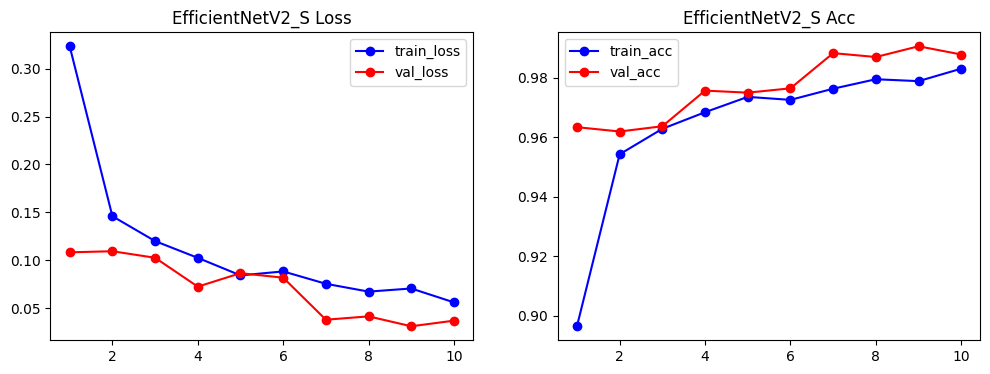

Evaluating:   0%|          | 0/204 [00:00<?, ?it/s]

Test acc: 0.9884951679705476
                         precision    recall  f1-score   support

 Camphor Bacterial Spot       0.96      0.99      0.97       481
   Camphor Healthy Leaf       0.99      0.94      0.97       483
      Camphor Shot Hole       0.98      1.00      0.99       477
HariTaki Bacterial Spot       0.99      0.98      0.98       482
  HariTaki Healthy Leaf       0.99      1.00      1.00       490
     HariTaki Shot Hole       0.98      0.99      0.98       481
      Neem Healthy Leaf       0.98      1.00      0.99       613
    Neem Powdary Milday       0.98      0.99      0.99       513
    Neem Shot Hole leaf       1.00      0.98      0.99       500
       Neem Yellow Leaf       1.00      0.98      0.99       513
    Sojina Healthy Leaf       1.00      1.00      1.00       516
       Sojina Spot Leaf       1.00      1.00      1.00       482
     Sojina Yellow Leaf       1.00      1.00      1.00       488

               accuracy                           0.99     

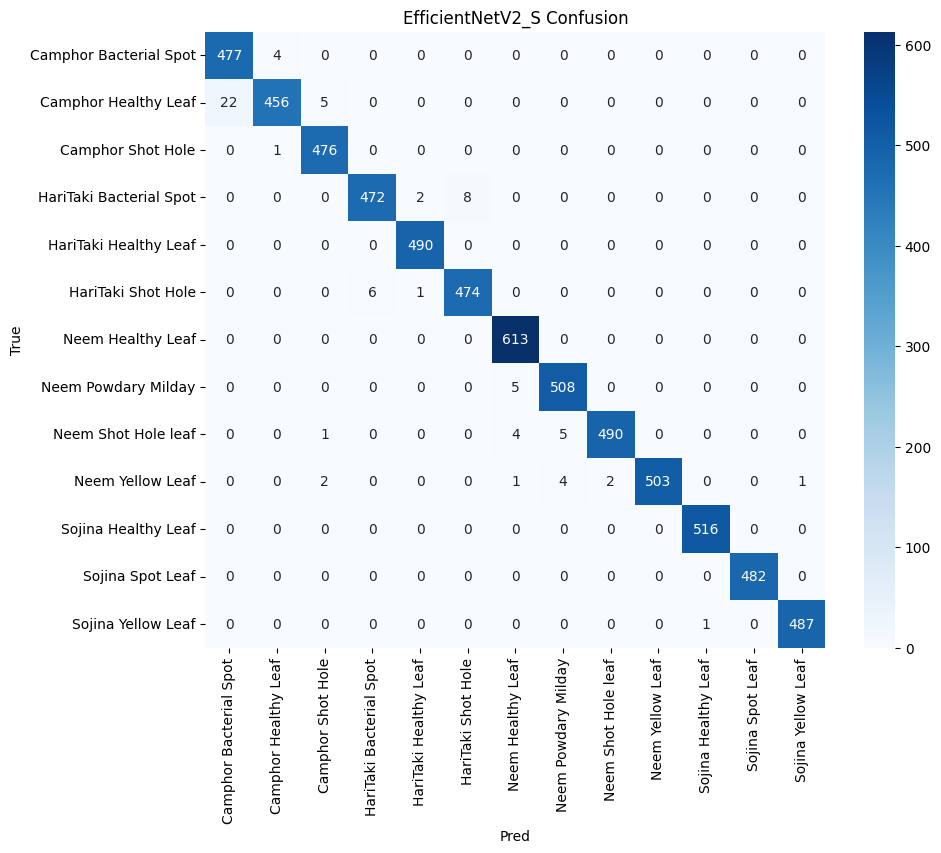

ExtractEmb:   0%|          | 0/204 [00:00<?, ?it/s]

Embeddings shape: (6519, 1280)


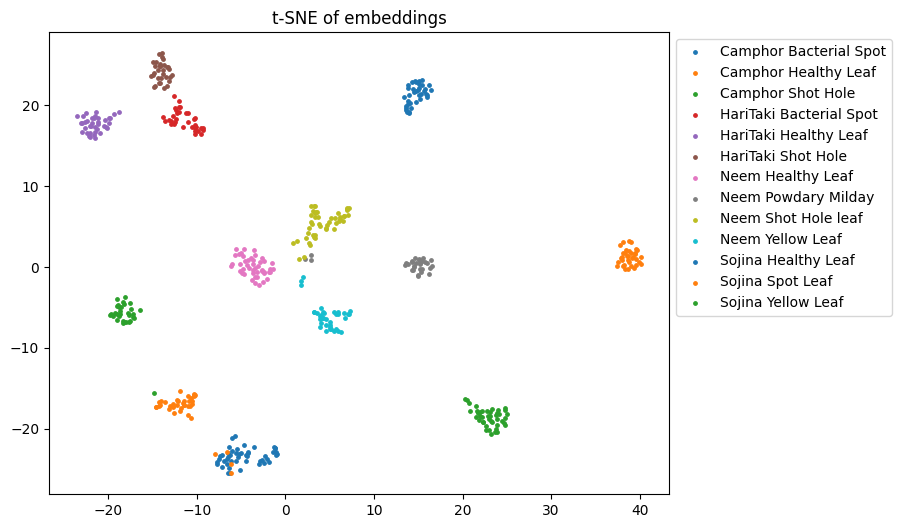

IndexError: list index out of range

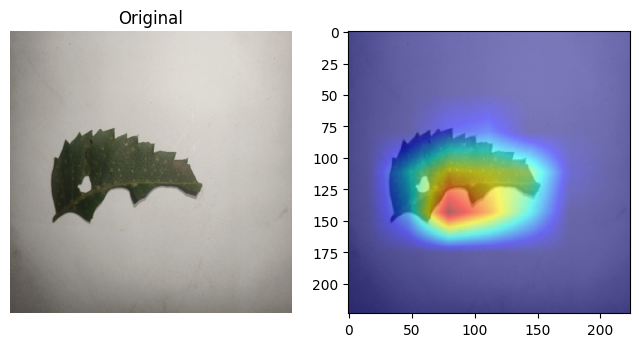

In [ ]:
# Quick usage examples (run selectively)
# 1) Plot training histories
for name, h in histories.items():
    plot_training_history(h, name)

# 2) Evaluate a model on test set (example: EfficientNet)
acc, report, cm, roc, y_true, y_pred, y_prob = evaluate_model(efficientnet_v2_s, test_loader, class_names)
print('Test acc:', acc); print(report)
plot_confusion(cm, class_names, title='EfficientNetV2_S Confusion')

# 3) t-SNE on embeddings extracted from model's penultimate layer
# Use the modified extractor (identity on classifier)
feat_extractor = build_feature_extractor(efficientnet_v2_s)
embs, labs = extract_embeddings(feat_extractor, test_loader)
print('Embeddings shape:', embs.shape)
plot_tsne(embs, labs, class_names, n_samples=500)

# 4) Run Grad-CAM on one test image (ensure pytorch-grad-cam installed)
# first pick an image from test_ds
sample_idx = 0
img_path = test_ds.image_paths[sample_idx]
cam_img, pred_idx = apply_gradcam_pytorch(efficientnet_v2_s, efficientnet_v2_s.features[-1], img_path, predict_transform, device)
plt.figure(figsize=(8,4)); plt.subplot(1,2,1); plt.imshow(Image.open(img_path).convert('RGB')); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cam_img); plt.title(f'Grad-CAM pred={class_names[pred_idx]}'); plt.axis('off')
plt.show()

# 5) LIME example
# visualize_lime(efficientnet_v2_s, predict_transform, img_path, class_names)

# 6) Anomaly detection example using feature extractor
feature_model = build_feature_extractor(efficientnet_v2_s)
anomaly_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
anomaly_indices, features = detect_anomalies_updated(feature_model, anomaly_loader)
print('Anomalies detected:', len(anomaly_indices))
plot_anomalous_images_from_dataset(test_ds, anomaly_indices, num_to_show=8)


Device for XAI: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /Users/hongviet/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /Users/hongviet/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:08<00:00, 9.79MB/s]



Loading weights from /Users/hongviet/Documents/ComputerVision/đề án cuối kì/results/saved_models/EfficientNetV2_S.pth
Loaded state_dict successfully
Found 30 images for XAI


XAI:   0%|          | 0/30 [00:00<?, ?it/s]

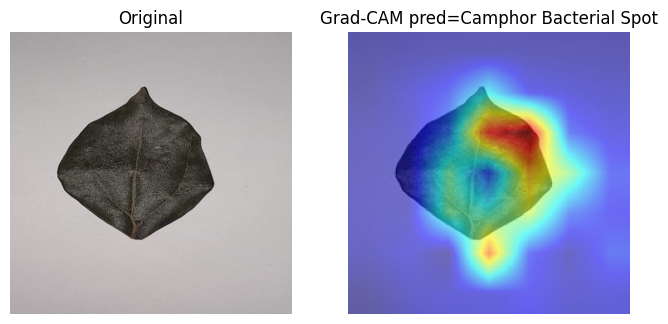

100%|██████████| 200/200 [00:07<00:00, 26.76it/s]



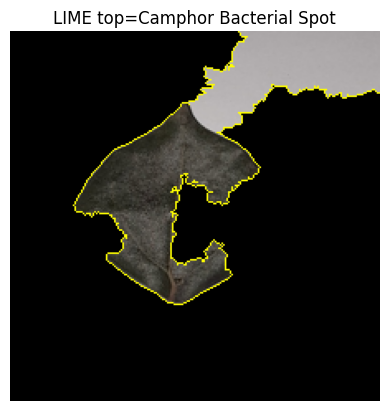

XAI:   3%|▎         | 1/30 [00:11<05:46, 11.94s/it]

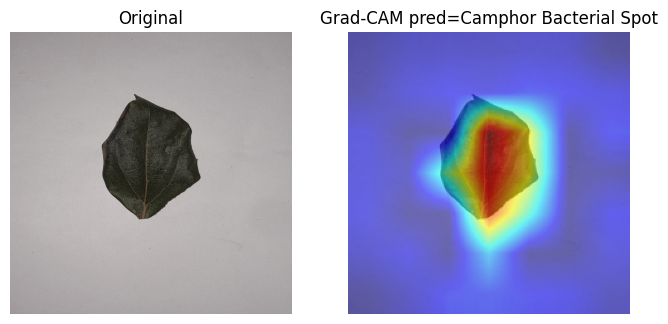

100%|██████████| 200/200 [00:07<00:00, 26.46it/s]



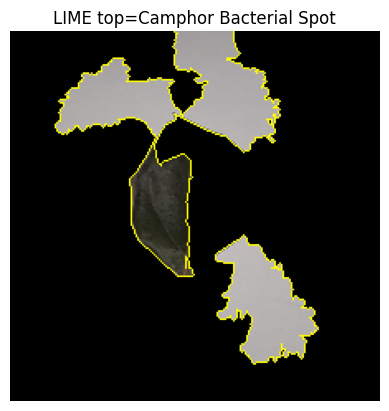

XAI:   7%|▋         | 2/30 [00:23<05:34, 11.93s/it]

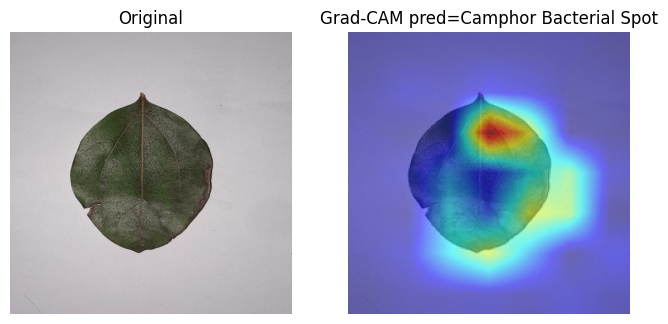

100%|██████████| 200/200 [00:07<00:00, 25.17it/s]



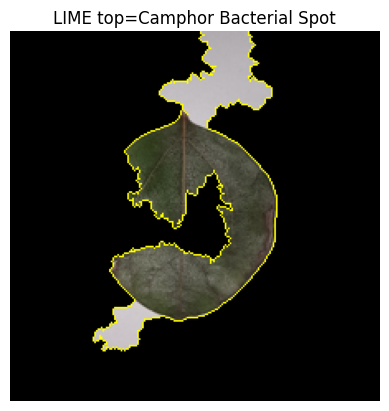

XAI:  10%|█         | 3/30 [00:37<05:47, 12.86s/it]

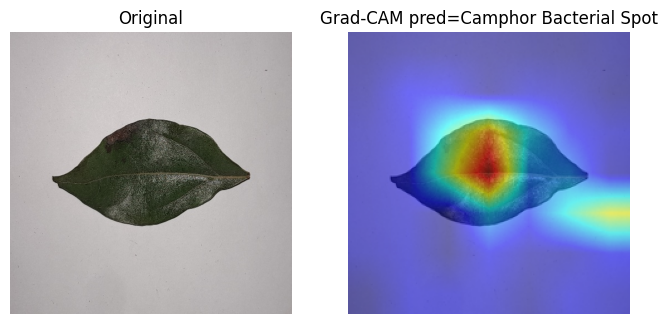

100%|██████████| 200/200 [00:07<00:00, 25.01it/s]



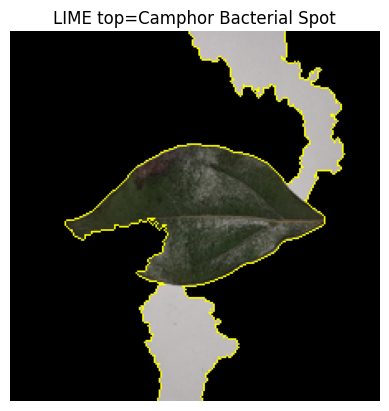

XAI:  13%|█▎        | 4/30 [00:51<05:40, 13.08s/it]

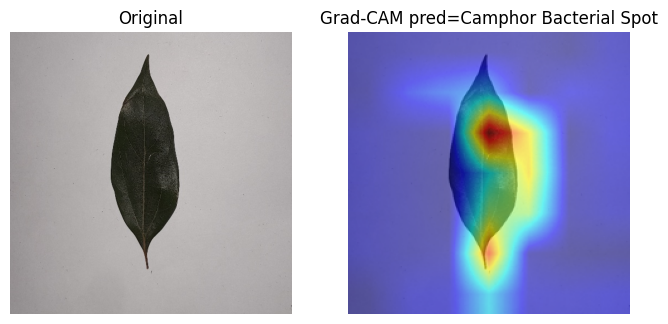

100%|██████████| 200/200 [00:08<00:00, 23.45it/s]



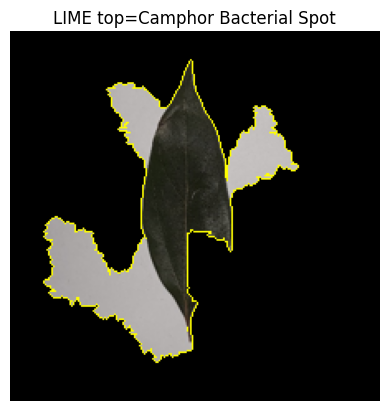

XAI:  17%|█▋        | 5/30 [01:05<05:38, 13.52s/it]

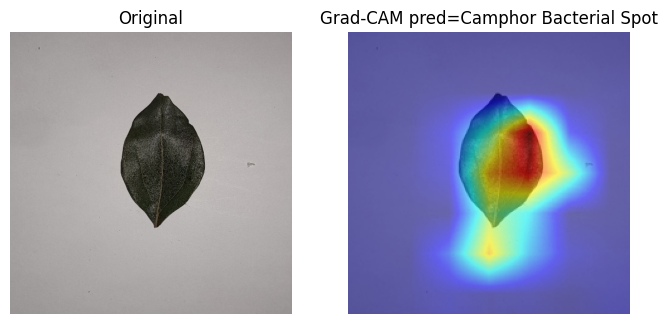

100%|██████████| 200/200 [00:07<00:00, 28.07it/s]



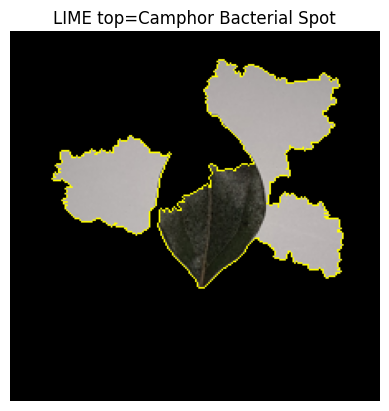

XAI:  20%|██        | 6/30 [01:17<05:15, 13.15s/it]

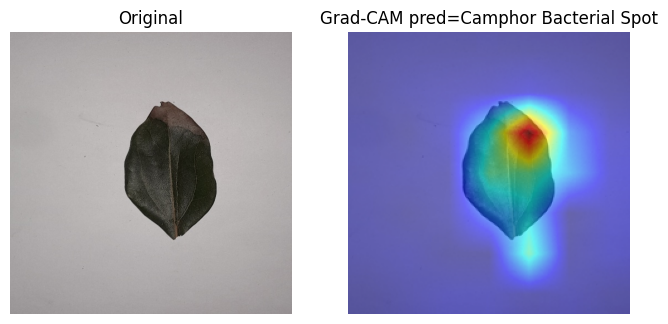

100%|██████████| 200/200 [00:08<00:00, 23.98it/s]



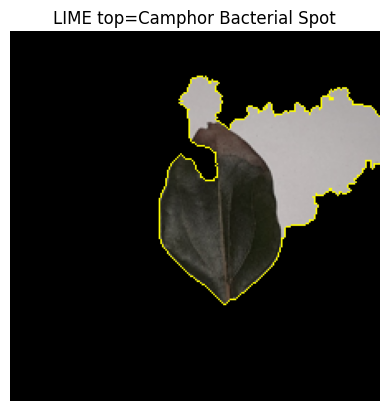

XAI:  23%|██▎       | 7/30 [01:32<05:11, 13.53s/it]

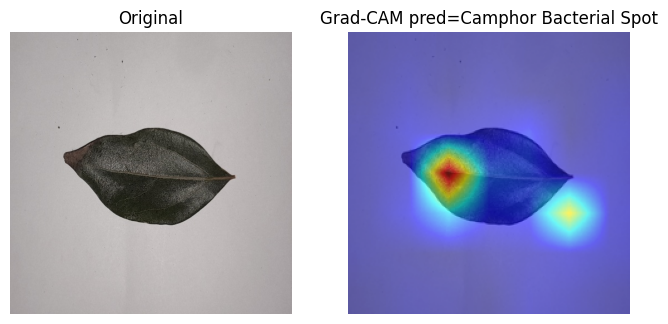

100%|██████████| 200/200 [00:07<00:00, 27.87it/s]



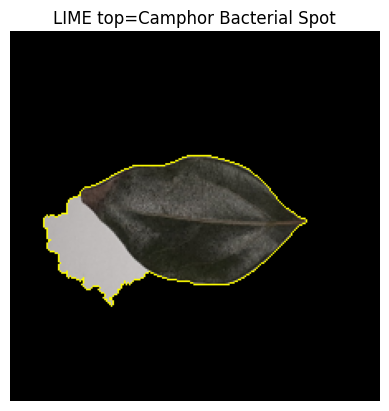

XAI:  27%|██▋       | 8/30 [01:44<04:49, 13.17s/it]

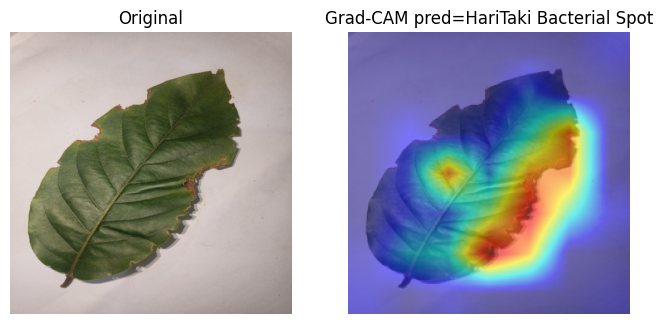

100%|██████████| 200/200 [00:07<00:00, 27.09it/s]



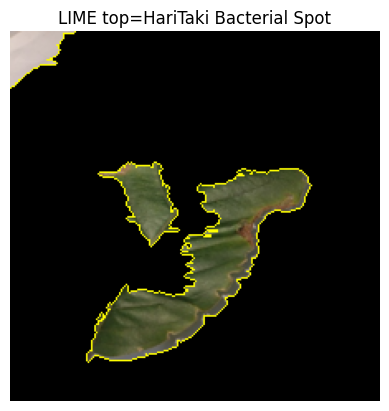

XAI:  30%|███       | 9/30 [01:57<04:31, 12.94s/it]

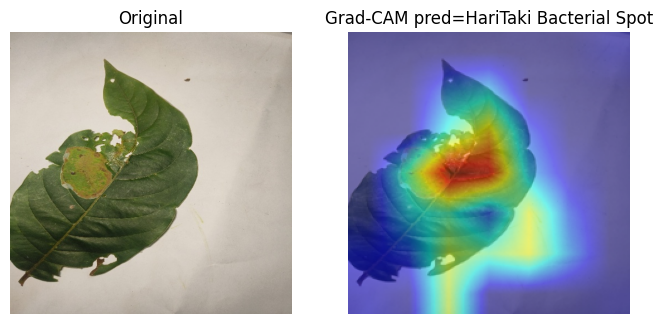

100%|██████████| 200/200 [00:08<00:00, 24.88it/s]



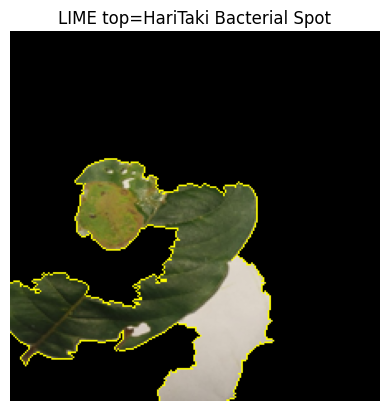

XAI:  33%|███▎      | 10/30 [02:10<04:21, 13.08s/it]

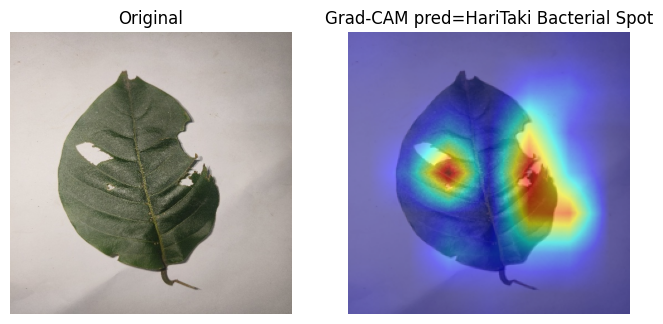

100%|██████████| 200/200 [00:07<00:00, 27.66it/s]



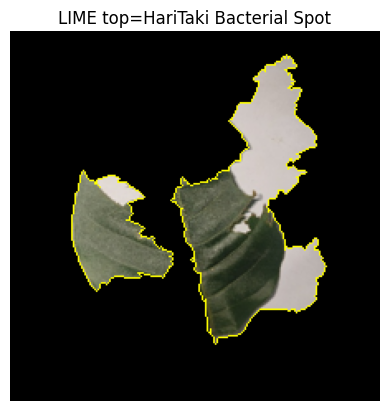

XAI:  37%|███▋      | 11/30 [02:22<04:02, 12.77s/it]

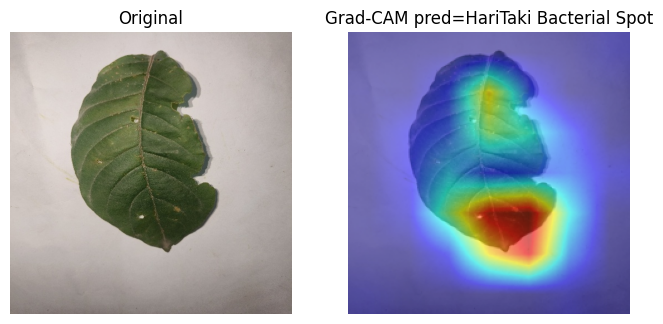

100%|██████████| 200/200 [00:08<00:00, 22.96it/s]



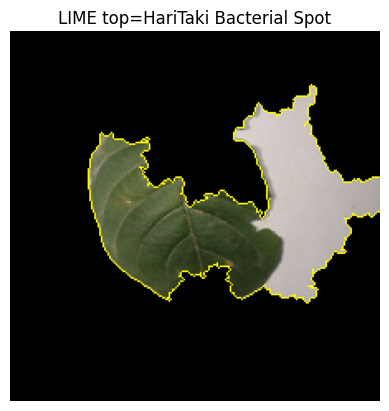

XAI:  40%|████      | 12/30 [02:36<03:58, 13.23s/it]

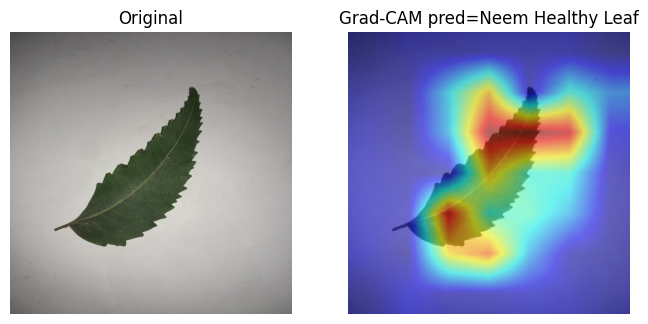

100%|██████████| 200/200 [00:09<00:00, 21.74it/s]



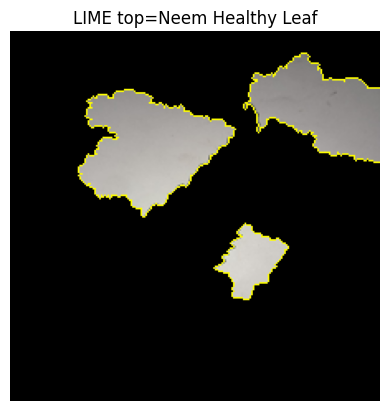

XAI:  43%|████▎     | 13/30 [02:52<03:56, 13.89s/it]

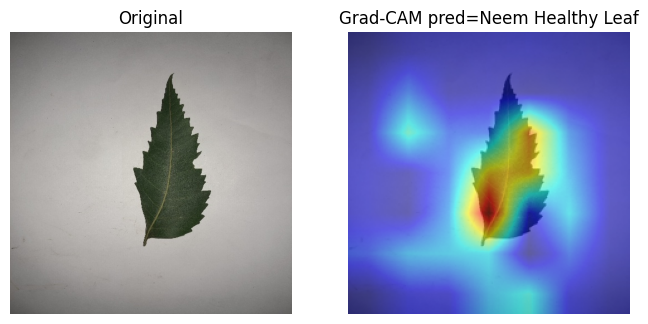

100%|██████████| 200/200 [00:10<00:00, 18.95it/s]



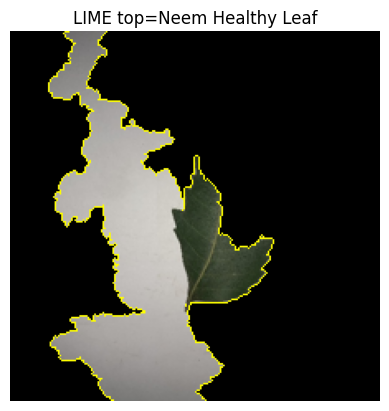

XAI:  47%|████▋     | 14/30 [03:09<04:00, 15.04s/it]

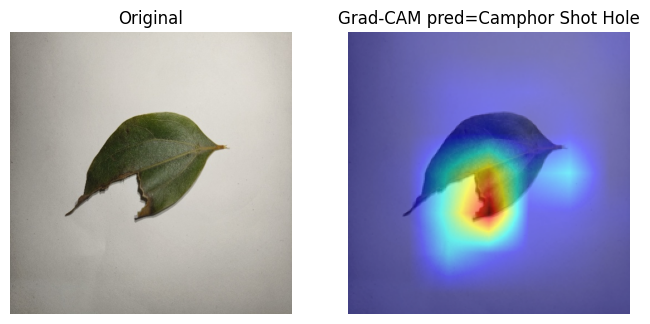

100%|██████████| 200/200 [00:11<00:00, 17.86it/s]



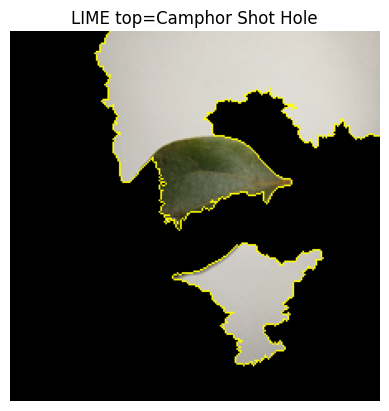

XAI:  50%|█████     | 15/30 [03:27<03:57, 15.80s/it]

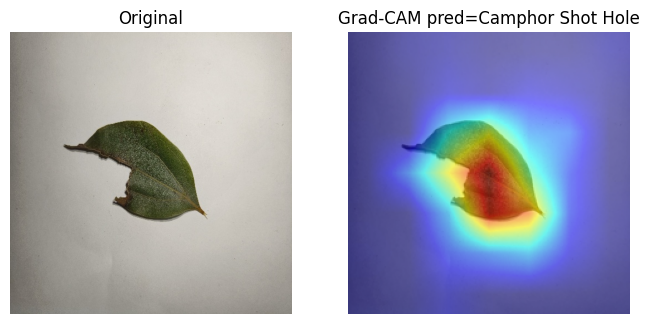

100%|██████████| 200/200 [00:09<00:00, 20.28it/s]



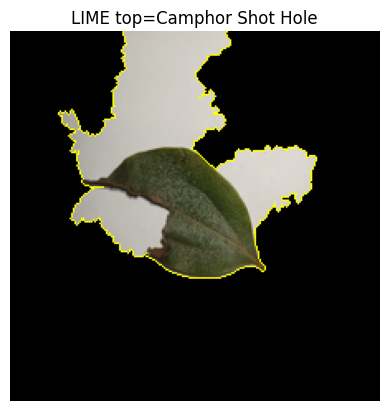

XAI:  53%|█████▎    | 16/30 [03:45<03:49, 16.37s/it]

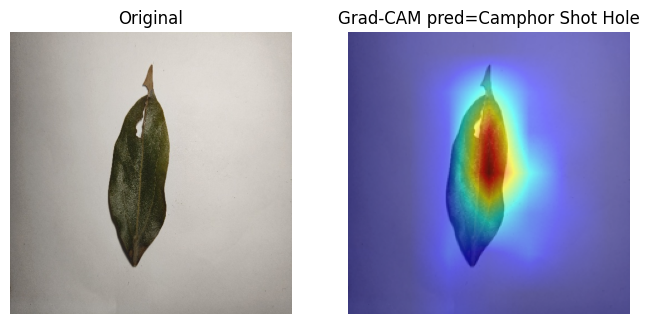

100%|██████████| 200/200 [00:11<00:00, 17.21it/s]



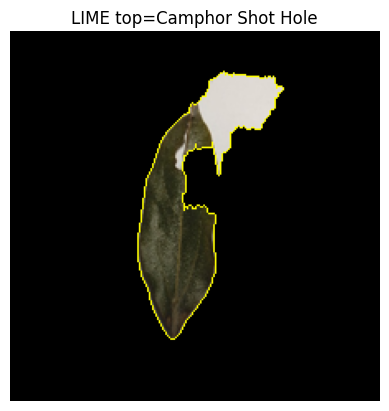

XAI:  57%|█████▋    | 17/30 [04:04<03:45, 17.37s/it]

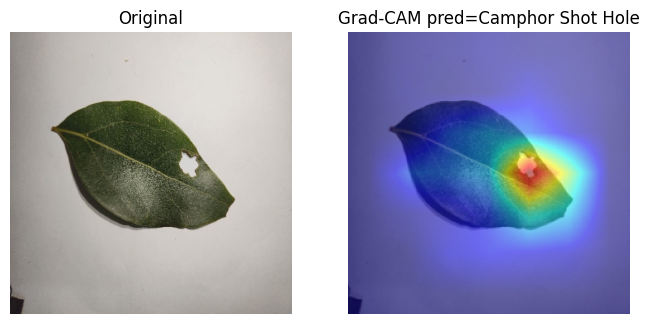

100%|██████████| 200/200 [00:08<00:00, 23.03it/s]



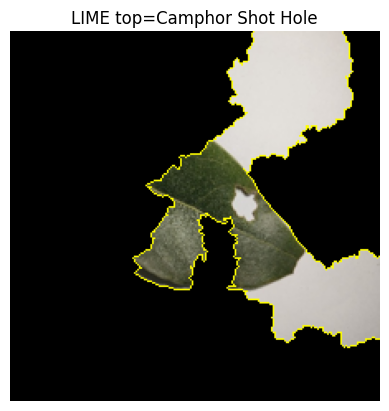

XAI:  60%|██████    | 18/30 [04:20<03:21, 16.80s/it]

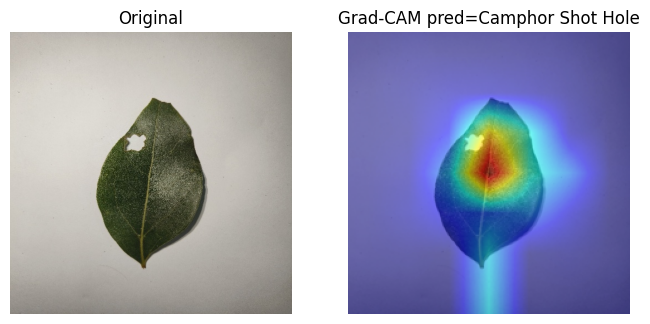

100%|██████████| 200/200 [00:08<00:00, 23.04it/s]



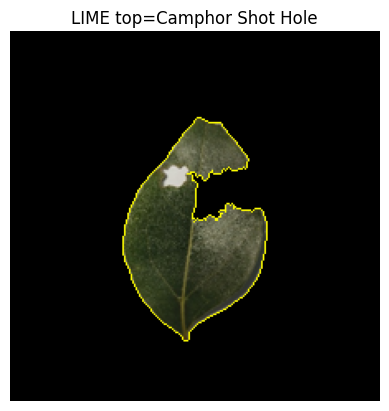

XAI:  63%|██████▎   | 19/30 [04:35<02:58, 16.24s/it]

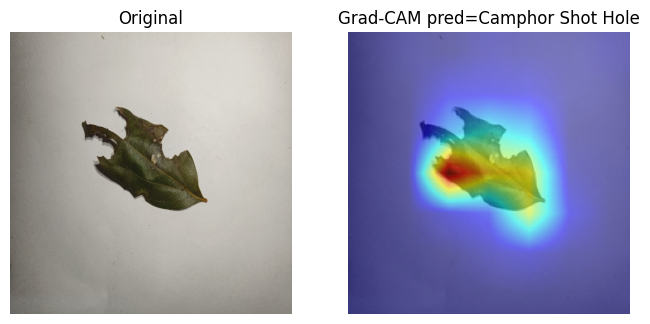

100%|██████████| 200/200 [00:09<00:00, 21.81it/s]



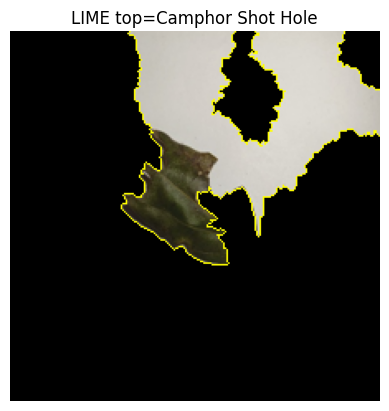

XAI:  67%|██████▋   | 20/30 [04:50<02:40, 16.02s/it]

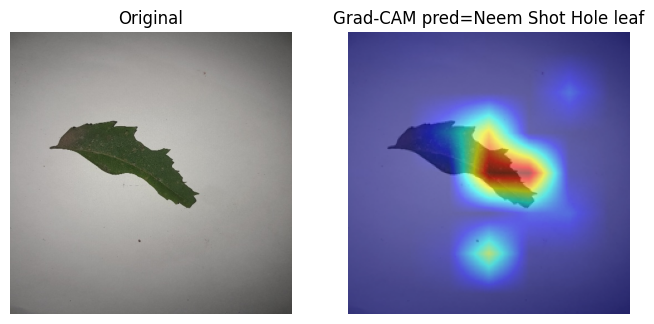

100%|██████████| 200/200 [00:09<00:00, 20.41it/s]



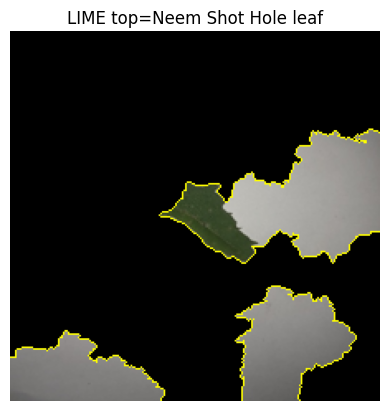

XAI:  70%|███████   | 21/30 [05:07<02:24, 16.10s/it]

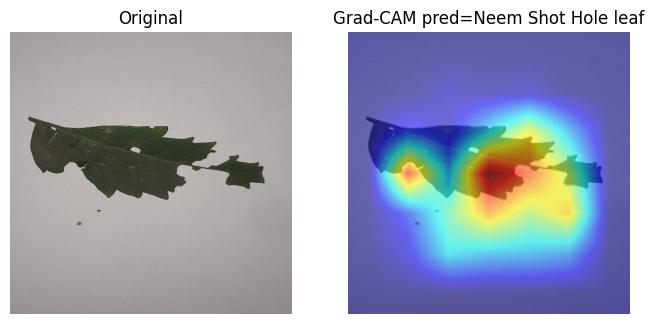

100%|██████████| 200/200 [00:08<00:00, 22.31it/s]



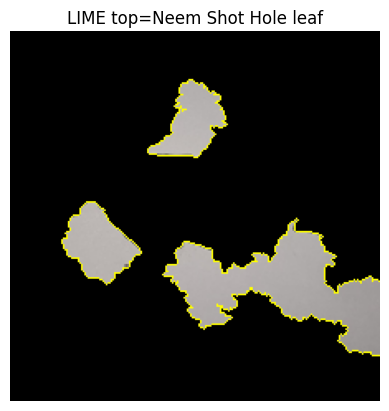

XAI:  73%|███████▎  | 22/30 [05:22<02:06, 15.81s/it]

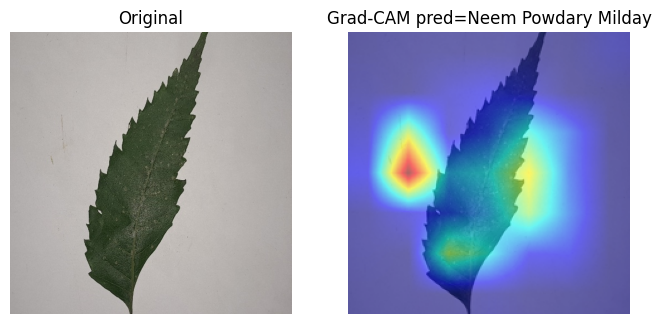

100%|██████████| 200/200 [00:09<00:00, 20.53it/s]



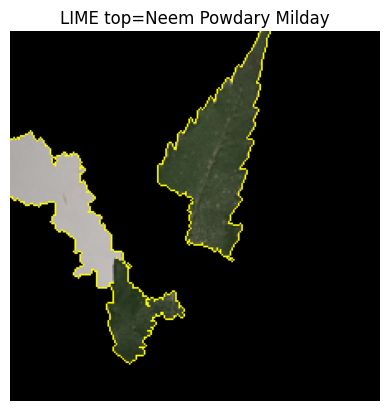

XAI:  77%|███████▋  | 23/30 [05:38<01:52, 16.00s/it]

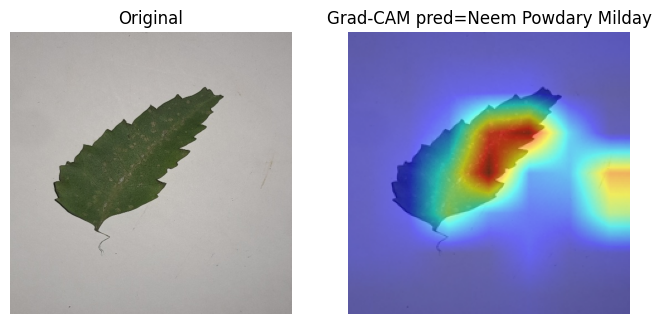

100%|██████████| 200/200 [00:08<00:00, 23.78it/s]



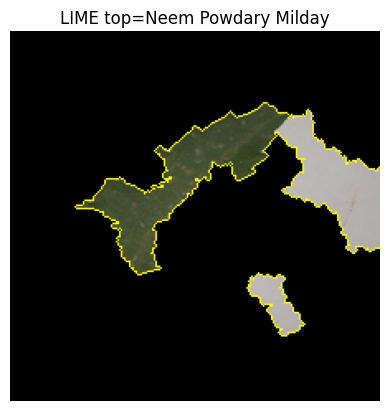

XAI:  80%|████████  | 24/30 [05:54<01:34, 15.82s/it]

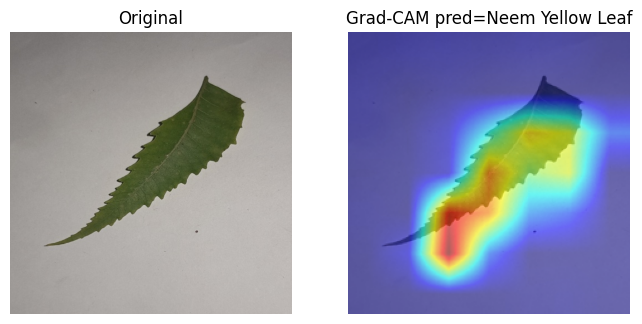

100%|██████████| 200/200 [00:07<00:00, 26.13it/s]



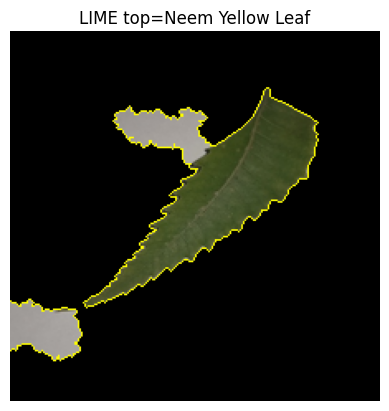

XAI:  83%|████████▎ | 25/30 [06:07<01:15, 15.18s/it]

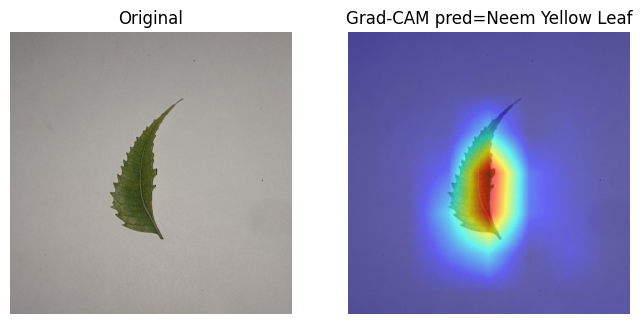

100%|██████████| 200/200 [00:08<00:00, 24.06it/s]



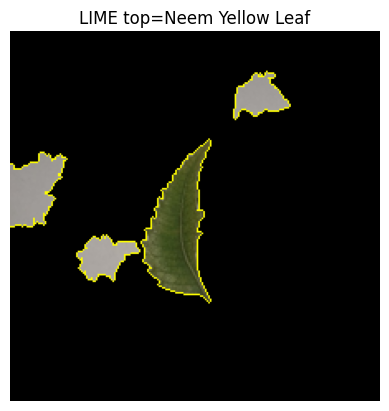

XAI:  87%|████████▋ | 26/30 [06:22<00:59, 14.97s/it]

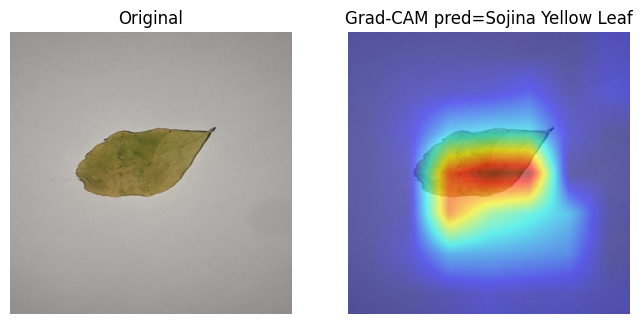

100%|██████████| 200/200 [00:08<00:00, 25.00it/s]



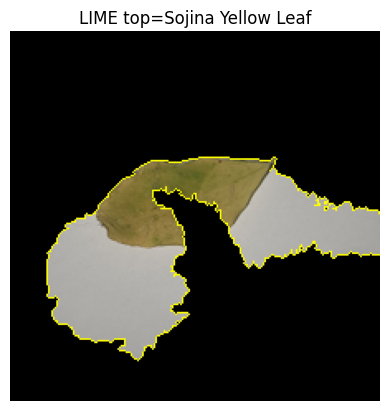

XAI:  90%|█████████ | 27/30 [06:36<00:44, 14.83s/it]

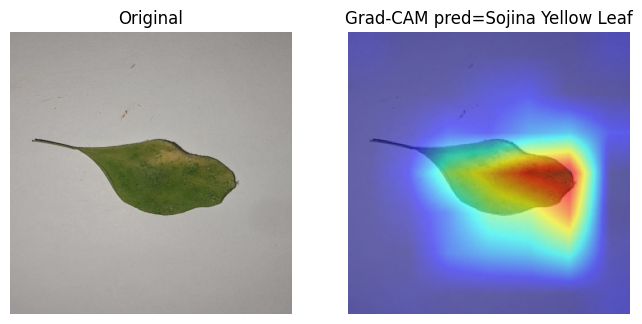

100%|██████████| 200/200 [00:09<00:00, 22.15it/s]



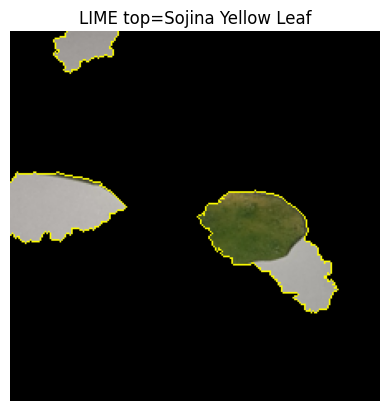

XAI:  93%|█████████▎| 28/30 [06:51<00:29, 14.90s/it]

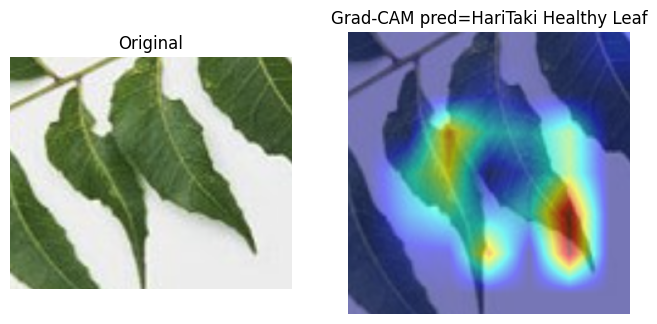

100%|██████████| 200/200 [00:08<00:00, 24.53it/s]



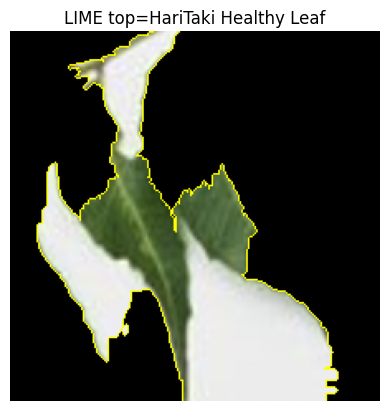

XAI:  97%|█████████▋| 29/30 [07:05<00:14, 14.67s/it]

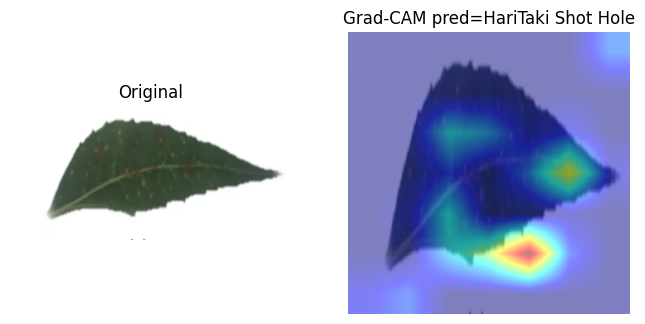

100%|██████████| 200/200 [00:08<00:00, 22.35it/s]



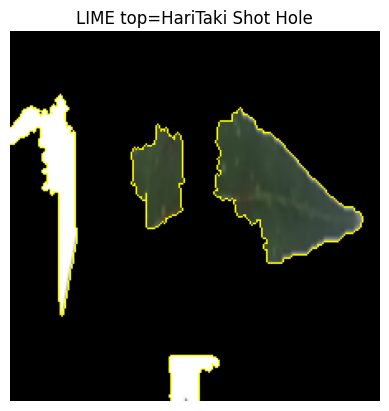

XAI: 100%|██████████| 30/30 [07:20<00:00, 14.68s/it]


In [32]:
# === NEW CELL: Load saved EfficientNetV2_S and run Grad-CAM + LIME on up to N images ===
# Edit the two paths below to point to your saved model and the folder with images to explain
saved_model_path = '/Users/hongviet/Documents/ComputerVision/đề án cuối kì/results/saved_models/EfficientNetV2_S.pth'  # <-- set this to your .pth file
images_dir = '/Users/hongviet/Documents/ComputerVision/đề án cuối kì/n'  # <-- set this to folder containing images you want to explain
n_images = 30

import glob
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device for XAI:', device)

# Recreate EfficientNetV2_S architecture (same classifier as used during training)
num_classes = len(class_names)  # relies on earlier cell that loaded class_names
model_xai = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
in_f_eff = model_xai.classifier[1].in_features
model_xai.classifier = nn.Sequential(nn.Linear(in_f_eff, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes))
model_xai = model_xai.to(device)

# Load weights (map to device). If your saved file is a state_dict it will load directly.
print('Loading weights from', saved_model_path)
state = torch.load(saved_model_path, map_location=device)
try:
    model_xai.load_state_dict(state)
    print('Loaded state_dict successfully')
except Exception as e:
    print('Direct load failed (maybe you saved a dict with extra keys). Trying strict=False:', e)
    try:
        model_xai.load_state_dict(state, strict=False)
        print('Loaded state_dict with strict=False')
    except Exception as e2:
        print('Failed to load weights:', e2)

model_xai.eval()

# find image files (recursive) and limit to n_images
exts = ('*.jpg','*.jpeg','*.png','*.bmp')
img_paths = []
for e in exts:
    img_paths.extend(glob.glob(os.path.join(images_dir, '**', e), recursive=True))
img_paths = sorted(img_paths)[:n_images]
print('Found', len(img_paths), 'images for XAI')

# Target layer for Grad-CAM: use last features block of EfficientNetV2_S (same as earlier usage)
try:
    target_layer = model_xai.features[-1]
except Exception:
    target_layer = None

# Loop and show Grad-CAM + LIME (uses apply_gradcam_pytorch and visualize_lime defined earlier)
from tqdm.auto import tqdm
for p in tqdm(img_paths, desc='XAI'):
    try:
        if target_layer is None:
            print('No target layer found for Grad-CAM; skipping Grad-CAM for', p)
        else:
            cam_img, pred_idx = apply_gradcam_pytorch(model_xai, target_layer, p, predict_transform, device)
            plt.figure(figsize=(8,4))
            plt.subplot(1,2,1); plt.imshow(Image.open(p).convert('RGB')); plt.title('Original'); plt.axis('off')
            plt.subplot(1,2,2); plt.imshow(cam_img); plt.title(f'Grad-CAM pred={class_names[pred_idx]}'); plt.axis('off')
            plt.show()
    except Exception as e:
        print('Grad-CAM error for', p, e)

    # LIME explanation (may be slower). visualize_lime will show its own plot.
    try:
        visualize_lime(model_xai, predict_transform, p, class_names)
    except Exception as e:
        print('LIME error for', p, e)

    # small pause so notebook can render figures progressively
    plt.pause(0.05)
